# SafeRL-Drive Phase-1 Colab driver

Use this notebook from VS Code with a Google Colab runtime. GitHub and `/content/safedrive` hold the live code. Google Drive holds persistent artifacts only at `/content/drive/MyDrive/SafeDrive`; do not run the repository from mounted Drive.

The smoke test, IDM baseline, PPO training, and SAC training are separate sections so long experiments can run in different Colab sessions. After every major experiment, copy its run directory to Drive. Set `FULL_TIMESTEPS = 1_000_000` in Section 1 only if you intentionally want a longer run.

## 1. Initialization

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/djdhillxn/safedrive.git"
REPO_DIR = Path("/content/safedrive")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT = DRIVE_MOUNT / "MyDrive" / "SafeDrive"
FULL_TIMESTEPS = 500_000
EVAL_EPISODES = 50
VIDEO_STEPS = 1000

print(f"Live checkout: {REPO_DIR}")
print(f"Artifact backup: {DRIVE_PROJECT}")
print(f"Training timesteps: {FULL_TIMESTEPS:,}")

Live checkout: /content/safedrive
Artifact backup: /content/drive/MyDrive/SafeDrive
Training timesteps: 500,000


## 2. Runtime and GPU check

In [2]:
import torch

print(f"Python: {sys.version.split()[0]}")
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], check=False)
else:
    print("nvidia-smi: unavailable")

if torch.cuda.is_available():
    print(f"PyTorch CUDA: available ({torch.cuda.get_device_name(0)})")
else:
    print("PyTorch CUDA: unavailable; MLP training can still run on CPU.")

Python: 3.12.13
PyTorch CUDA: available (NVIDIA L4)


## 3. Mount Google Drive

In [4]:
from google.colab import drive

drive.mount(str(DRIVE_MOUNT))
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
connection_file = DRIVE_PROJECT / "colab_connection_test.txt"
connection_file.write_text(
    f"Connected at {datetime.now(timezone.utc).isoformat()}\n",
    encoding="utf-8",
)
print(f"Drive read/write ready: {connection_file}")

Mounted at /content/drive
Drive read/write ready: /content/drive/MyDrive/SafeDrive/colab_connection_test.txt


## 4. Clone or pull the repository

The repository is public, so no GitHub token is required. Push local changes before this step when Colab needs the newest revision.

In [5]:
if (REPO_DIR / ".git").exists():
    git_command = ["git", "-C", str(REPO_DIR), "pull", "--ff-only"]
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository.")
else:
    if REPO_DIR.exists():
        REPO_DIR.rmdir()
    git_command = ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)]

git_result = subprocess.run(git_command, capture_output=True, text=True)
if git_result.returncode:
    print(git_result.stdout[-4000:])
    print(git_result.stderr[-4000:])
    raise RuntimeError("Git clone/pull failed; see the output above.")

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
git_commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print(f"Repository ready at commit {git_commit[:12]}")

Repository ready at commit 55699b6ac53e


## 5. Install SafeRL-Drive

In [6]:
import importlib.metadata

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "gym"],
    check=False,
    capture_output=True,
    text=True,
)
install_result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", "--progress-bar", "off", "-e", "."],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
)
if install_result.returncode:
    print(install_result.stdout[-8000:])
    print(install_result.stderr[-8000:])
    raise RuntimeError("SafeRL-Drive installation failed; see the output above.")

packages = ["metadrive-simulator", "stable-baselines3", "gymnasium", "torch"]
versions = {name: importlib.metadata.version(name) for name in packages}
print(json.dumps(versions, indent=2))

{
  "metadrive-simulator": "0.4.3",
  "stable-baselines3": "2.9.0",
  "gymnasium": "1.3.0",
  "torch": "2.11.0+cu128"
}


### Shared artifact helpers

In [7]:
def read_latest_run(name):
    pointer = REPO_DIR / "runs" / f"latest_{name}.txt"
    if not pointer.exists():
        raise FileNotFoundError(f"Latest-run pointer not found: {pointer}")
    run_dir = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_dir.is_absolute():
        run_dir = REPO_DIR / run_dir
    return run_dir.resolve()

def require_shell_success(label):
    exit_code = get_ipython().user_ns.get("_exit_code", 0)
    if exit_code:
        raise RuntimeError(f"{label} failed with exit code {exit_code}.")

def show_json(path):
    path = Path(path)
    print(json.dumps(json.loads(path.read_text(encoding="utf-8")), indent=2))

def copy_to_drive(path, category="runs"):
    path = Path(path)
    target = DRIVE_PROJECT / category / path.name
    target.parent.mkdir(parents=True, exist_ok=True)
    if path.is_dir():
        target.mkdir(parents=True, exist_ok=True)
        if shutil.which("rsync"):
            subprocess.run(["rsync", "-a", f"{path}/", f"{target}/"], check=True)
        else:
            shutil.copytree(path, target, dirs_exist_ok=True)
    else:
        shutil.copy2(path, target)
    print(f"Copied to Drive: {target}")
    return target

## 6. Smoke test

This is only an installation/wiring check and is not a report result.

In [18]:
!python -m scripts.train --config configs/smoke_test.yaml
require_shell_success("Smoke test")

SMOKE_RUN_DIR = read_latest_run("smoke")
show_json(SMOKE_RUN_DIR / "eval" / "final_unseen_summary.json")
copy_to_drive(SMOKE_RUN_DIR, category="smoke_tests")

2026-07-21 01:50:16.743471: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 01:50:16.812817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_015020_smoke_test_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Fu

PosixPath('/content/drive/MyDrive/SafeDrive/smoke_tests/20260721_015020_smoke_test_ppo_seed0')

## 7. Rule-based IDM baseline

In [8]:
!python -m scripts.evaluate_baseline --config configs/ppo_mvp.yaml --episodes {EVAL_EPISODES} --prefix idm_unseen
require_shell_success("IDM baseline")

IDM_RUN_DIR = read_latest_run("idm")
show_json(IDM_RUN_DIR / "eval" / "idm_unseen_summary.json")
copy_to_drive(IDM_RUN_DIR)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_023109_idm_baseline_seed0
INFO: Evaluating IDMPolicy for 50 episodes on unseen seeds beginning at 1000.
Evaluating: 100% 50/50 [04:25<00:00,  5.31s/it]
INFO: IDM baseline complete: runs/20260721_023109_idm_baseline_seed0/eval/idm_unseen_summary.json
{
  "episodes": 50,
  "mean_return": 394.48852090106493,
  "std_return": 241.37833241859207,
  "mean_length": 526.26,
  "success_rate": 0.5,
  "collision_rate": 0.28,
  "out_of_road_rate": 0.2,
  "timeout_or_max_step_rate": 0.02,
  "mean_cost": 0.48,
  "mean_route_completion": 0.6966180358737663,
  "mean_speed_km_h": 27.04608873858742
}
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/20260721_023109_idm_baseline_seed0


PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_023109_idm_baseline_seed0')

## 8. PPO training

In [9]:
!python -m scripts.train --config configs/ppo_mvp.yaml train.total_timesteps={FULL_TIMESTEPS} eval.episodes={EVAL_EPISODES}
require_shell_success("PPO training")

PPO_RUN_DIR = read_latest_run("ppo")
ppo_summary = PPO_RUN_DIR / "eval" / "final_unseen_summary.json"
print(f"PPO run: {PPO_RUN_DIR}")
print(f"PPO summary: {ppo_summary}")
show_json(ppo_summary)
copy_to_drive(PPO_RUN_DIR)

2026-07-21 02:35:51.987794: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 02:35:52.058012: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_023556_ppo_mvp_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Futur

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_023556_ppo_mvp_ppo_seed0')

In [12]:
print("hello")

hello


## 9. SAC training

In [10]:
!python -m scripts.train --config configs/sac_mvp.yaml train.total_timesteps={FULL_TIMESTEPS} eval.episodes={EVAL_EPISODES}
require_shell_success("SAC training")

SAC_RUN_DIR = read_latest_run("sac")
sac_summary = SAC_RUN_DIR / "eval" / "final_unseen_summary.json"
print(f"SAC run: {SAC_RUN_DIR}")
print(f"SAC summary: {sac_summary}")
show_json(sac_summary)
copy_to_drive(SAC_RUN_DIR)

2026-07-21 03:24:19.878063: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 03:24:19.949863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_032424_sac_mvp_sac_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Futur

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_032424_sac_mvp_sac_seed0')

## 10. Evaluate best PPO and SAC models

In [11]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

if (PPO_RUN_DIR / "models" / "best_model.zip").exists():
    !python -m scripts.evaluate --run-dir "{PPO_RUN_DIR}" --model best --episodes {EVAL_EPISODES} --prefix best_unseen
    require_shell_success("PPO best-model evaluation")
    print(PPO_RUN_DIR / "eval" / "best_unseen_summary.json")
else:
    print("PPO best model is missing. Evaluate --model final if needed.")

if (SAC_RUN_DIR / "models" / "best_model.zip").exists():
    !python -m scripts.evaluate --run-dir "{SAC_RUN_DIR}" --model best --episodes {EVAL_EPISODES} --prefix best_unseen
    require_shell_success("SAC best-model evaluation")
    print(SAC_RUN_DIR / "eval" / "best_unseen_summary.json")
else:
    print("SAC best model is missing. Evaluate --model final if needed.")

copy_to_drive(PPO_RUN_DIR)
copy_to_drive(SAC_RUN_DIR)

2026-07-21 06:20:21.178026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 06:20:21.249052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
INFO: Loading best model: /content/safedrive/runs/20260721_023556_ppo_mvp_ppo_seed0/models/best_model.zip
/usr

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_032424_sac_mvp_sac_seed0')

## 11. Record one rollout per trained agent

The recorder falls back to the final model with a clear warning if a best model was not saved.

In [12]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

!python -m scripts.record_video --run-dir "{PPO_RUN_DIR}" --model best --steps {VIDEO_STEPS}
require_shell_success("PPO video")
!python -m scripts.record_video --run-dir "{SAC_RUN_DIR}" --model best --steps {VIDEO_STEPS}
require_shell_success("SAC video")

copy_to_drive(PPO_RUN_DIR)
copy_to_drive(SAC_RUN_DIR)

2026-07-21 06:30:57.614195: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 06:30:57.685400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
INFO: Loading best model: /content/safedrive/runs/20260721_023556_ppo_mvp_ppo_seed0/models/best_model.zip
/usr

RuntimeError: PPO video failed with exit code 1.

## 12. Compare IDM, PPO, and SAC

INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Phase-1 comparison written: runs/phase1_comparison.csv
INFO: Comparison plot written: runs/phase1_comparison.png
INFO: Training comparison written: runs/phase1_training_returns.png


,name,episodes,mean_return,std_return,mean_length,success_rate,collision_rate,out_of_road_rate,timeout_or_max_step_rate,mean_cost,mean_route_completion,mean_speed_km_h,run_dir,summary_path
0,IDM,50,394.488521,241.378332,526.26,0.50,0.28,0.20,0.02,0.48,0.696618,27.046089,/content/safedrive/runs/20260721_023109_idm_ba...,/content/safedrive/runs/20260721_023109_idm_ba...
1,PPO,50,254.318737,161.518255,578.56,0.16,0.12,0.54,0.18,0.66,0.597896,23.863502,/content/safedrive/runs/20260721_023556_ppo_mv...,/content/safedrive/runs/20260721_023556_ppo_mv...
2,SAC,50,63.006623,65.336449,905.16,0.00,0.00,0.14,0.86,0.14,0.174585,4.218184,/content/safedrive/runs/20260721_032424_sac_mv...,/content/safedrive/runs/20260721_032424_sac_mv...


{
  "generated_at_utc": "2026-07-21T06:34:17.836754+00:00",
  "experiments": [
    {
      "name": "IDM",
      "episodes": 50,
      "mean_return": 394.48852090106493,
      "std_return": 241.37833241859207,
      "mean_length": 526.26,
      "success_rate": 0.5,
      "collision_rate": 0.28,
      "out_of_road_rate": 0.2,
      "timeout_or_max_step_rate": 0.02,
      "mean_cost": 0.48,
      "mean_route_completion": 0.6966180358737663,
      "mean_speed_km_h": 27.04608873858742,
      "run_dir": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0",
      "summary_path": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0/eval/idm_unseen_summary.json"
    },
    {
      "name": "PPO",
      "episodes": 50,
      "mean_return": 254.3187371043007,
      "std_return": 161.51825477257682,
      "mean_length": 578.56,
      "success_rate": 0.16,
      "collision_rate": 0.12,
      "out_of_road_rate": 0.54,
      "timeout_or_max_step_rate": 0.18,
      "mean_cost": 0.66,
   

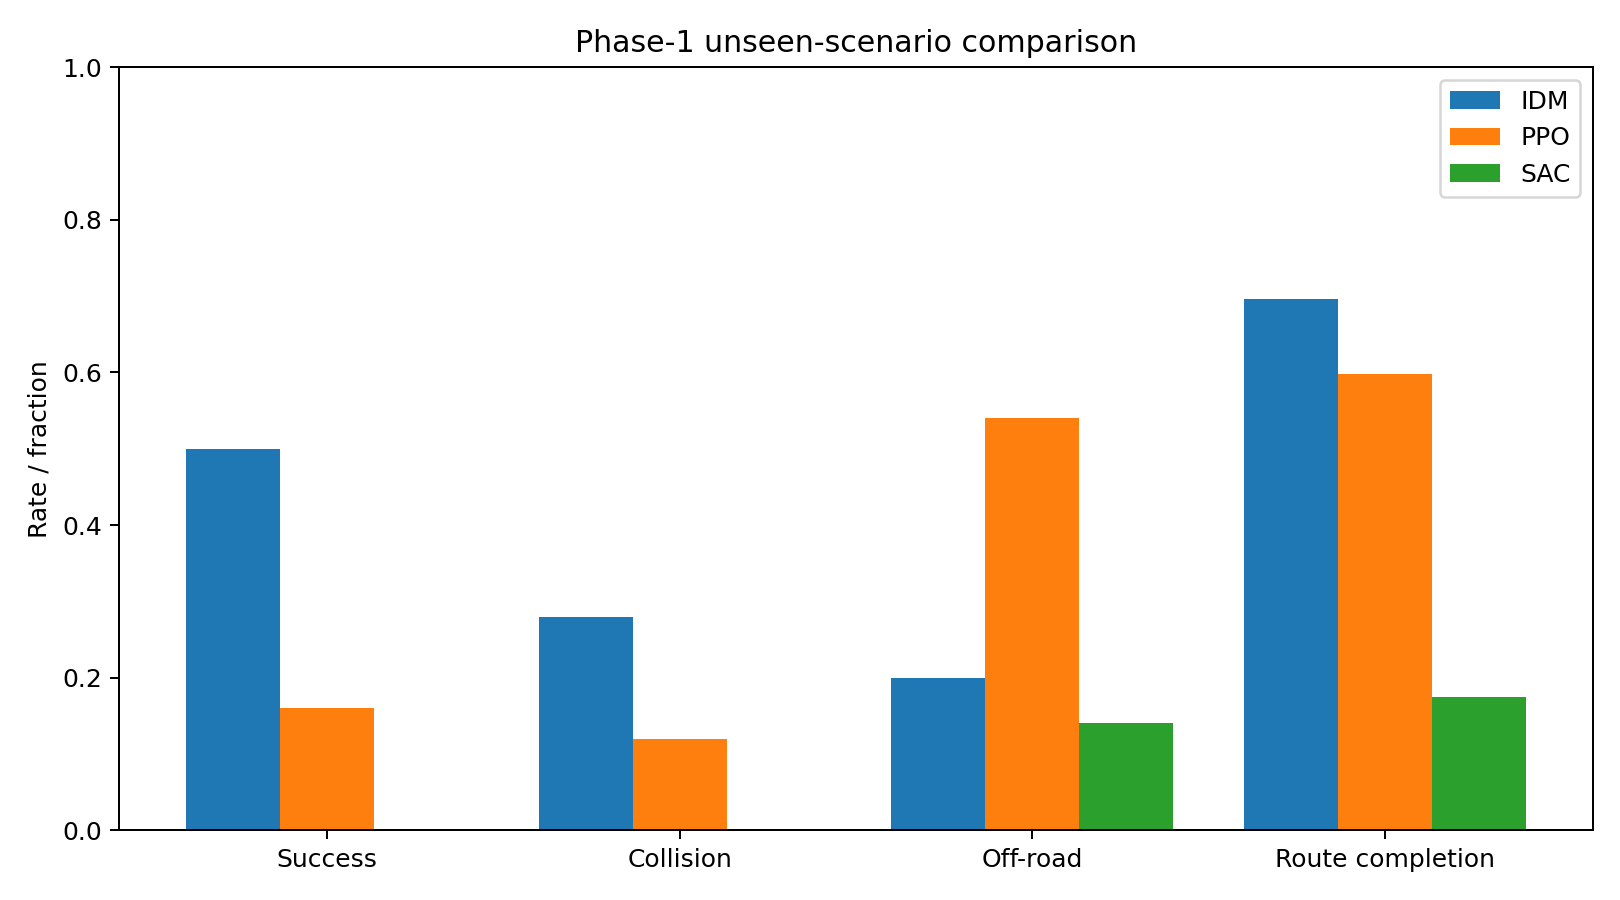

Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.csv
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.json
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.png
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_training_returns.png


In [13]:
import pandas as pd
from IPython.display import Image, display

!python -m scripts.compare_runs --phase1
require_shell_success("Phase-1 comparison")

comparison_csv = REPO_DIR / "runs" / "phase1_comparison.csv"
comparison_json = REPO_DIR / "runs" / "phase1_comparison.json"
comparison_png = REPO_DIR / "runs" / "phase1_comparison.png"
display(pd.read_csv(comparison_csv))
show_json(comparison_json)
display(Image(filename=str(comparison_png)))

for path in [comparison_csv, comparison_json, comparison_png]:
    copy_to_drive(path)
training_comparison = REPO_DIR / "runs" / "phase1_training_returns.png"
if training_comparison.exists():
    copy_to_drive(training_comparison)

## 13. Build the LaTeX report

In [14]:
if shutil.which("latexmk"):
    !latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex
    require_shell_success("LaTeX report build")
else:
    print("latexmk is not installed in this runtime. Build locally from the repository root with:")
    print("latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex")

report_pdf = REPO_DIR / "reports" / "main.pdf"
if report_pdf.exists():
    copy_to_drive(report_pdf, category="reports")

latexmk is not installed in this runtime. Build locally from the repository root with:
latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex


## 14. Final artifact sync

In [15]:
(DRIVE_PROJECT / "runs").mkdir(parents=True, exist_ok=True)
(DRIVE_PROJECT / "reports").mkdir(parents=True, exist_ok=True)

if shutil.which("rsync"):
    !rsync -a "{REPO_DIR}/runs/" "{DRIVE_PROJECT}/runs/"
    require_shell_success("Run artifact sync")
    !rsync -a "{REPO_DIR}/reports/" "{DRIVE_PROJECT}/reports/"
    require_shell_success("Report artifact sync")
else:
    shutil.copytree(REPO_DIR / "runs", DRIVE_PROJECT / "runs", dirs_exist_ok=True)
    shutil.copytree(REPO_DIR / "reports", DRIVE_PROJECT / "reports", dirs_exist_ok=True)

print(f"Final artifact sync complete: {DRIVE_PROJECT}")

Final artifact sync complete: /content/drive/MyDrive/SafeDrive


## Finished

The detailed execution record is inside each run's `logs/` directory and `run_metadata.json`. Disconnect the Colab runtime when finished so it does not continue consuming compute units.